# Задание 1

## Brute force with ORB

In [1]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

In [2]:
img1 = cv.imread('D:/PyProjects/SLAM_Algorithms/SLAM-Algorithms/img/box.png')
img1 = cv.cvtColor(img1, cv.COLOR_BGR2GRAY)   

img2 = cv.imread('D:/PyProjects/SLAM_Algorithms/SLAM-Algorithms/img/box_in_scene.png')
img2 = cv.cvtColor(img2, cv.COLOR_BGR2GRAY)  
# Initiate ORB detector
orb = cv.ORB_create()
# find the keypoints and descriptors with ORB
kp1, des1 = orb.detectAndCompute(img1,None)
kp2, des2 = orb.detectAndCompute(img2,None)

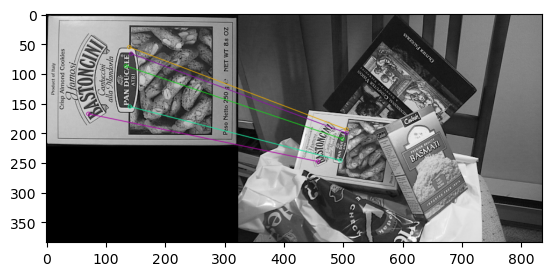

In [4]:
# create BFMatcher object
bf = cv.BFMatcher(cv.NORM_HAMMING, crossCheck=True)
# Match descriptors.
matches = bf.match(des1,des2)
# Sort them in the order of their distance.
matches = sorted(matches, key = lambda x:x.distance)
# Draw first 10 matches.
img3 = cv.drawMatches(img1,kp1,img2,kp2,matches[:5],None,flags=cv.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
plt.imshow(img3)
plt.show()

## Brute-Force Matching with SIFT Descriptors and Ratio Test

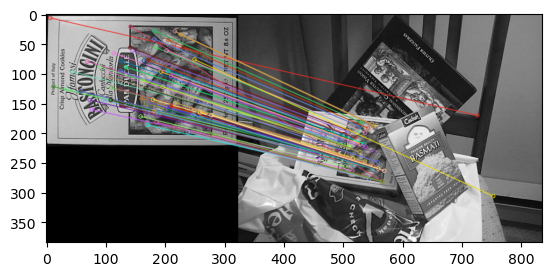

((< cv2.DMatch 000001FECC7039F0>, < cv2.DMatch 000001FECCB7B970>),
 (< cv2.DMatch 000001FECCB7B7D0>, < cv2.DMatch 000001FECCB7AB70>),
 (< cv2.DMatch 000001FECCB7A4B0>, < cv2.DMatch 000001FECCB7A450>))

In [8]:
img1 = cv.imread('D:/PyProjects/SLAM_Algorithms/SLAM-Algorithms/img/box.png')
img1 = cv.cvtColor(img1, cv.COLOR_BGR2GRAY)   

img2 = cv.imread('D:/PyProjects/SLAM_Algorithms/SLAM-Algorithms/img/box_in_scene.png')
img2 = cv.cvtColor(img2, cv.COLOR_BGR2GRAY)  

# Initiate SIFT detector
sift = cv.SIFT_create()
# find the keypoints and descriptors with SIFT
kp1, des1 = sift.detectAndCompute(img1,None)
kp2, des2 = sift.detectAndCompute(img2,None)
# BFMatcher with default params
bf = cv.BFMatcher()
matches = bf.knnMatch(des1,des2,k=2)
# Apply ratio test
good = []
for m,n in matches:
    if m.distance < 0.75*n.distance:
        good.append([m])
# cv.drawMatchesKnn expects list of lists as matches.
img3 = cv.drawMatchesKnn(img1,kp1,img2,kp2,good,None,flags=cv.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
plt.imshow(img3)
plt.show()
matches[:3]

## FLANN based Matcher

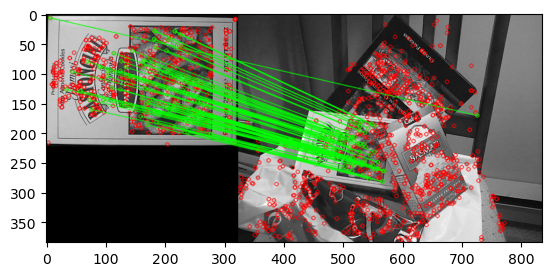

In [7]:
img1 = cv.imread('D:/PyProjects/SLAM_Algorithms/SLAM-Algorithms/img/box.png')
img1 = cv.cvtColor(img1, cv.COLOR_BGR2GRAY)   

img2 = cv.imread('D:/PyProjects/SLAM_Algorithms/SLAM-Algorithms/img/box_in_scene.png')
img2 = cv.cvtColor(img2, cv.COLOR_BGR2GRAY)  


# Initiate SIFT detector
sift = cv.SIFT_create()
# find the keypoints and descriptors with SIFT
kp1, des1 = sift.detectAndCompute(img1,None)
kp2, des2 = sift.detectAndCompute(img2,None)
# FLANN parameters
FLANN_INDEX_KDTREE = 1
index_params = dict(algorithm = FLANN_INDEX_KDTREE, trees = 5)
search_params = dict(checks=50)   # or pass empty dictionary
flann = cv.FlannBasedMatcher(index_params,search_params)
matches = flann.knnMatch(des1,des2,k=2)
# Need to draw only good matches, so create a mask
matchesMask = [[0,0] for i in range(len(matches))]
# ratio test as per Lowe's paper
for i,(m,n) in enumerate(matches):
    if m.distance < 0.7*n.distance:
        matchesMask[i]=[1,0]
draw_params = dict(matchColor = (0,255,0),
                   singlePointColor = (255,0,0),
                   matchesMask = matchesMask,
                   flags = cv.DrawMatchesFlags_DEFAULT)
img3 = cv.drawMatchesKnn(img1,kp1,img2,kp2,matches,None,**draw_params)
plt.imshow(img3,)
plt.show()

# Задание 2

## Feature Matching + Homography to find Objects 

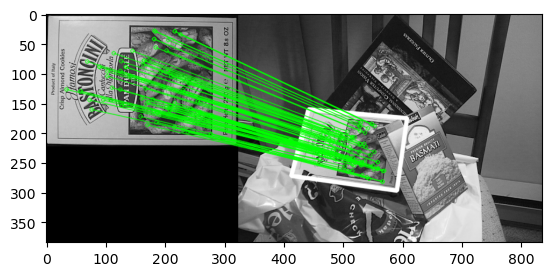

(<matplotlib.image.AxesImage at 0x1fecce1ec60>, None)

In [15]:
MIN_MATCH_COUNT = 10
img1 = cv.imread('D:/PyProjects/SLAM_Algorithms/SLAM-Algorithms/img/box.png')
img1 = cv.cvtColor(img1, cv.COLOR_BGR2GRAY)   

img2 = cv.imread('D:/PyProjects/SLAM_Algorithms/SLAM-Algorithms/img/box_in_scene.png')
img2 = cv.cvtColor(img2, cv.COLOR_BGR2GRAY)

# Initiate SIFT detector
sift = cv.SIFT_create()
# find the keypoints and descriptors with SIFT
kp1, des1 = sift.detectAndCompute(img1,None)
kp2, des2 = sift.detectAndCompute(img2,None)
FLANN_INDEX_KDTREE = 1
index_params = dict(algorithm = FLANN_INDEX_KDTREE, trees = 5)
search_params = dict(checks = 50)
flann = cv.FlannBasedMatcher(index_params, search_params)
matches = flann.knnMatch(des1,des2,k=2)
# store all the good matches as per Lowe's ratio test.
good = []
for m,n in matches:
    if m.distance < 0.7*n.distance:
        good.append(m)  

if len(good)>MIN_MATCH_COUNT:
    src_pts = np.float32([ kp1[m.queryIdx].pt for m in good ]).reshape(-1,1,2)
    dst_pts = np.float32([ kp2[m.trainIdx].pt for m in good ]).reshape(-1,1,2)
    M, mask = cv.findHomography(src_pts, dst_pts, cv.RANSAC,5.0)
    matchesMask = mask.ravel().tolist()
    h,w = img1.shape
    pts = np.float32([ [0,0],[0,h-1],[w-1,h-1],[w-1,0] ]).reshape(-1,1,2)
    dst = cv.perspectiveTransform(pts,M)
    img2 = cv.polylines(img2,[np.int32(dst)],True,255,5, cv.LINE_AA)
else:
    print( "Not enough matches are found - {}/{}".format(len(good), MIN_MATCH_COUNT) )
    matchesMask = None


draw_params = dict(matchColor = (0,255,0), # draw matches in green color
                   singlePointColor = None,
                   matchesMask = matchesMask, # draw only inliers
                   flags = 2)
img3 = cv.drawMatches(img1,kp1,img2,kp2,good,None,**draw_params)
plt.imshow(img3, 'gray'),plt.show()